In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

# Load the preprocessed datasets
"""
X_train = pd.read_csv("preprocessed_data/X_train.csv")
X_test = pd.read_csv("preprocessed_data/X_test.csv")
y_train = pd.read_csv("preprocessed_data/y_train.csv")
y_test = pd.read_csv("preprocessed_data/y_test.csv")
"""


# 1. Load the single processed file
df = pd.read_csv("preprocessed_data/processed_mushrooms.csv")

In [71]:
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,class,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,0,0,0,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [72]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_probs = {}
        self.feature_probs = {}

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.classes = np.unique(y)

        # Prior P(y)
        for c in self.classes:
            self.class_probs[c] = np.sum(y == c) / n_samples


        self.feature_probs = {
            c: [defaultdict(float) for _ in range(X.shape[1])]
            for c in self.classes
        }

        for c in self.classes:
            X_c = X[y == c]

            for i in range(X.shape[1]):
                feature_values = X.iloc[:, i].unique()
                total_count = len(X_c)

                for val in feature_values:
                    count = np.sum(X_c.iloc[:, i] == val)

                    # Laplace smoothing
                    prob = (count + self.alpha) / (
                        total_count + self.alpha * len(feature_values)
                    )

                    self.feature_probs[c][i][val] = prob

    def predict(self, X):
        predictions = []

        for _, row in X.iterrows():
            class_scores = {}

            for c in self.classes:
                log_prob = np.log(self.class_probs[c])

                for i, val in enumerate(row):
                    prob = self.feature_probs[c][i].get(val, 1e-9)
                    log_prob += np.log(prob)

                class_scores[c] = log_prob

            predictions.append(max(class_scores, key=class_scores.get))


        return np.array(predictions)

In [74]:
model = NaiveBayes(alpha=1.0)

model.fit(X_train, y_train)

#### Evaluate Performance

Naive Bayes Test Accuracy: 0.8929

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       843
           1       0.96      0.81      0.88       782

    accuracy                           0.89      1625
   macro avg       0.90      0.89      0.89      1625
weighted avg       0.90      0.89      0.89      1625



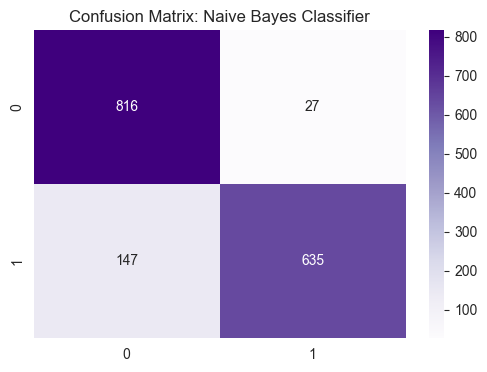

In [75]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
print(f"Naive Bayes Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Naive Bayes has no loss curve since it's not an iteration model
'''
plt.plot(model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()
'''

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Naive Bayes Classifier')
plt.show()

Actual & Prediction Comparison

In [76]:
y_test_labels = encoders['class'].inverse_transform(y_test)
y_pred_labels = encoders['class'].inverse_transform(y_pred)

pd.DataFrame({
    "Actual": y_test_labels,
    "Predicted": y_pred_labels
}).head(20)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1
5,1,1
6,1,0
7,1,1
8,0,0
9,0,0
